In [1]:
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
labels = pd.read_csv("/Users/chinmay/Projects/Galaxy Classification/data/processed/galaxy_labels.csv")

labels.head()

,GalaxyID,Galaxy_Class
0,100008,Spiral
1,100023,Barred Spiral
2,100053,Oval
3,100078,Elliptical
4,100090,Elliptical


In [3]:
labels["Galaxy_Class"].value_counts()

Galaxy_Class
Oval              13068
Elliptical        12039
Spiral            11826
Edge-on Spiral     6680
Disk               4831
Ring Galaxy        4263
Barred Spiral      3390
Irregular          2565
Cigar              1586
Merger             1220
Other               110
Name: count, dtype: int64

In [4]:
encoder = LabelEncoder()

labels["Label"] = encoder.fit_transform(labels["Galaxy_Class"])

labels.head()

,GalaxyID,Galaxy_Class,Label
0,100008,Spiral,10
1,100023,Barred Spiral,0
2,100053,Oval,8
3,100078,Elliptical,4
4,100090,Elliptical,4


In [5]:
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

label_mapping

{'Barred Spiral': np.int64(0),
 'Cigar': np.int64(1),
 'Disk': np.int64(2),
 'Edge-on Spiral': np.int64(3),
 'Elliptical': np.int64(4),
 'Irregular': np.int64(5),
 'Merger': np.int64(6),
 'Other': np.int64(7),
 'Oval': np.int64(8),
 'Ring Galaxy': np.int64(9),
 'Spiral': np.int64(10)}

In [6]:
train_df, val_df = train_test_split(
    labels,
    test_size=0.2,
    stratify=labels["Label"],
    random_state=42
)

print("Training Images :", len(train_df))
print("Validation Images:", len(val_df))

Training Images : 49262
Validation Images: 12316


In [7]:
IMAGE_DIR = Path("../data/raw/images_training_rev1")

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
class GalaxyDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = self.image_dir / f"{row['GalaxyID']}.jpg"

        image = Image.open(image_path).convert("RGB")

        label = row["Label"]

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
train_dataset = GalaxyDataset(
    train_df,
    IMAGE_DIR,
    train_transform
)

val_dataset = GalaxyDataset(
    val_df,
    IMAGE_DIR,
    val_transform
)

In [11]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [12]:
images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])


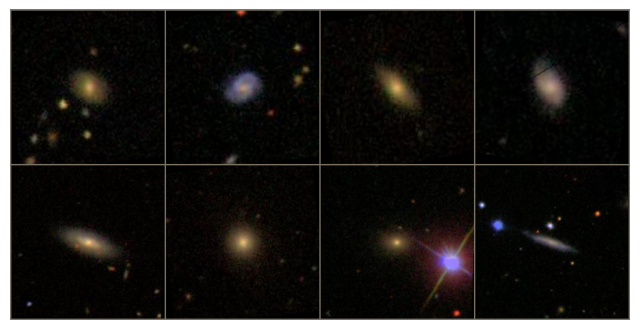

In [13]:
import torchvision

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

grid = torchvision.utils.make_grid(images[:8], nrow=4)

grid = grid * std + mean
grid = torch.clamp(grid, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [14]:
print("Training Samples   :", len(train_dataset))
print("Validation Samples :", len(val_dataset))

print("Number of Classes  :", len(encoder.classes_))
print("Classes            :", list(encoder.classes_))

Training Samples   : 49262
Validation Samples : 12316
Number of Classes  : 11
Classes            : ['Barred Spiral', 'Cigar', 'Disk', 'Edge-on Spiral', 'Elliptical', 'Irregular', 'Merger', 'Other', 'Oval', 'Ring Galaxy', 'Spiral']
